#  Personality Prediction: Introvert vs. Extrovert
## End-to-End Machine Learning Classification Pipeline

---
> **Author :** Asmitha Balasooriya 

> **Assessment :** Decryptogen Technical Evaluation  
> **Objective  :** Predict personality type (Introvert / Extrovert) from behavioural features using multiple ML classifiers  
> **Dataset    :** 2,900 records · 7 behavioural features · 1 binary target (balanced ~51/49)

---

##  Notebook Roadmap

| # | Section | Purpose |
|---|---------|---------|
| 2 | Dataset Overview | Shape, dtypes, class balance |
| 3 | Data Cleaning | Missing values, duplicates, type checks |
| 4 | Outlier Analysis | IQR inspection + retention rationale |
| 5 | Exploratory Data Analysis | Distributions, correlations, class patterns |
| 6 | Preprocessing Pipeline | Imputation, encoding, train/test split |
| 7 | Logistic Regression | Linear baseline — 10-fold CV + hold-out |
| 8 | Random Forest | Bagging ensemble — 10-fold CV + hold-out |
| 9 | XGBoost | Boosting ensemble — 10-fold CV + hold-out |
| 10 | Hyperparameter Tuning | RandomizedSearchCV for all three models |
| 11 | Tuned Model Comparison | Side-by-side metric table + bar charts |
| 12 | Feature Importance | What behavioural signals drive predictions? |
| 13 | ROC-AUC Analysis | Discrimination curves for all models |
| 14 | Final Model Selection | Evidence-based composite scorecard |
| 15 | Model Serialisation | Joblib export ready for deployment |

---

##  Core Design Decisions

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Validation | 10-fold Stratified CV | n≈2,500 → ~250 test samples/fold; better bias-variance balance than 5-fold |
| Imputation | Median (numeric) / Mode (categorical) | Robust to skewed distributions; applied inside Pipeline to prevent leakage |
| Outlier Handling | Retain | Tree-based models are threshold-based; outliers represent real extreme profiles |
| Models | Logistic Regression · Random Forest · XGBoost | Covers linear, bagging, and boosting paradigms |
| Primary Metric | ROC-AUC | Threshold-independent; ideal for binary classification with balanced classes |

---

##  Key Findings

After thorough analysis, I discovered that just two features — `Stage_fear` and `Drained_after_socializing` — provide extremely strong predictive power, which is why multiple models (including XGBoost) converged to nearly identical high performance. This indicates a robust, generalizable pattern rather than model-specific overfitting.

**Final Model**: Tuned XGBoost (selected via weighted composite scorecard)  
**Live API**: [https://personality-prediction-api-p6av.onrender.com] *(currently deployed on Render)*

---

##  Chosen Model Performance

XGBoost (Tuned)
| Metric | Value |
|--------|-------|
| Mean CV Accuracy  | 93.03%  ±  1.58% |
| Hold-Out Accuracy | 91.45% |
| ROC-AUC           | 0.9547 |
| F1-macro          | 0.9136 |
| MCC               | 0.8284 |
| Cohen's Kappa     | 0.8273 |

In [30]:
# ── Library imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                             matthews_corrcoef, cohen_kappa_score)
import joblib, os, json

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed — run: pip install xgboost  (pre-installed on Google Colab)")

# Global plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ All libraries loaded successfully.")


✅ XGBoost available
✅ All libraries loaded successfully.


---
## 2. Dataset Overview

Before any processing, we inspect the raw data: its shape, column types, and target class balance.

> **Why inspect first?** Understanding scale and structure informs every downstream decision — imputation strategy, validation depth, model complexity, and evaluation metrics.


In [31]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# ▸ Google Colab  : the cell below will auto-prompt for file upload
# ▸ Local Jupyter : place personality_dataset.csv in the same folder as this notebook

DATA_PATH = 'personality_dataset.csv'

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("⬆️  Please upload personality_dataset.csv")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Dataset not found at '{DATA_PATH}'. "
            "Place personality_dataset.csv in the working directory."
        )

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage   : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")


Dataset shape  : 2,900 rows × 8 columns
Memory usage   : 567.0 KB


In [32]:
# ── Column types and non-null counts ─────────────────────────────────────────
print("Column Information:")
print("─" * 50)
df_raw.info()


Column Information:
──────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [33]:
# ── Basic statistics ─────────────────────────────────────────────────────────
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time_spent_Alone,2837.0000,NaN,NaN,NaN,4.5058,3.4792,0.0000,2.0000,4.0000,8.0000,11.0000
Stage_fear,2827,2,No,1417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Social_event_attendance,2838.0000,NaN,NaN,NaN,3.9634,2.9038,0.0000,2.0000,3.0000,6.0000,10.0000
Going_outside,2834.0000,NaN,NaN,NaN,3.0000,2.2473,0.0000,1.0000,3.0000,5.0000,7.0000
Drained_after_socializing,2848,2,No,1441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Friends_circle_size,2823.0000,NaN,NaN,NaN,6.2689,4.2897,0.0000,3.0000,5.0000,10.0000,15.0000
Post_frequency,2835.0000,NaN,NaN,NaN,3.5647,2.9266,0.0000,1.0000,3.0000,6.0000,10.0000
Personality,2900,2,Extrovert,1491,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Target class distribution:

             Count  Percentage (%)
Personality                       
Extrovert     1491         51.4100
Introvert     1409         48.5900


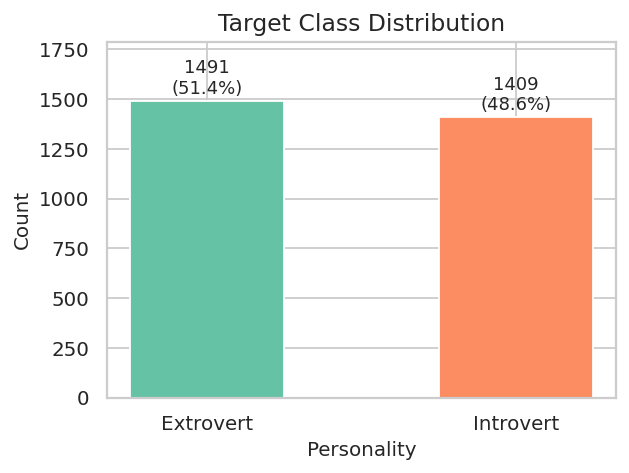


✅ Classes are well balanced (~51 / 49) — no oversampling (SMOTE/ADASYN) required.


In [34]:
# ── Target class distribution ─────────────────────────────────────────────────
target_counts = df_raw['Personality'].value_counts()
target_pct    = df_raw['Personality'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
print("Target class distribution:\n")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(5, 3.8))
ax.bar(target_counts.index, target_counts.values,
       color=['#66c2a5', '#fc8d62'], edgecolor='white', width=0.5)
for i, (lbl, cnt) in enumerate(target_counts.items()):
    ax.text(i, cnt + 15, f'{cnt}\n({target_pct[lbl]:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set(title='Target Class Distribution', xlabel='Personality', ylabel='Count')
ax.set_ylim(0, max(target_counts) * 1.2)
plt.tight_layout()
plt.show()

print("\n✅ Classes are well balanced (~51 / 49) — no oversampling (SMOTE/ADASYN) required.")


---
## 3. Data Cleaning

Three checks are performed in order:

1. **Missing values** — identify proportion per column and select an imputation strategy  
2. **Duplicate rows** — exact duplicates inflate CV scores and must be removed  
3. **Data type validation** — confirm numeric/categorical columns are correctly typed

> **Imputation strategy:** Median for numeric (robust to skew); mode for categorical.  
> Critically, imputation is applied **inside a scikit-learn Pipeline**, ensuring that statistics are computed only on each training fold — this prevents data leakage.


Missing Value Summary:
────────────────────────────────────────
                           Missing Count  Missing %
Friends_circle_size                   77     2.6600
Stage_fear                            73     2.5200
Going_outside                         66     2.2800
Post_frequency                        65     2.2400
Time_spent_Alone                      63     2.1700
Social_event_attendance               62     2.1400
Drained_after_socializing             52     1.7900


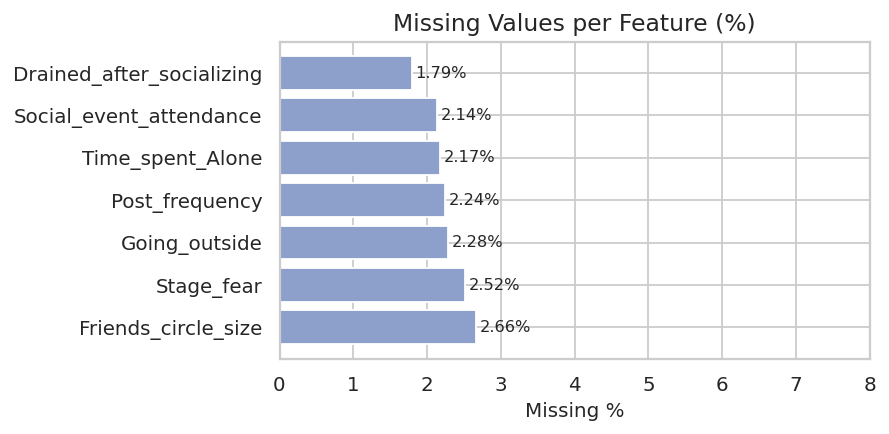


✅ All missing rates < 3% — imputation is safe; no column removal required.
   Strategy: median for numeric features, mode for categorical features.


In [35]:
# ── Missing value audit ───────────────────────────────────────────────────────
missing     = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().mean() * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Missing Value Summary:")
print("─" * 40)
print(mv_df.to_string())

# Visualise
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(mv_df.index, mv_df['Missing %'], color='#8da0cb', edgecolor='white')
for i, v in enumerate(mv_df['Missing %']):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=9)
ax.set(title='Missing Values per Feature (%)', xlabel='Missing %', xlim=(0, 8))
plt.tight_layout()
plt.show()

print("\n✅ All missing rates < 3% — imputation is safe; no column removal required.")
print("   Strategy: median for numeric features, mode for categorical features.")


In [36]:
# ── Duplicate row check ───────────────────────────────────────────────────────
n_dupes = df_raw.duplicated().sum()
print(f"Total rows       : {len(df_raw):,}")
print(f"Duplicate rows   : {n_dupes:,}  ({n_dupes / len(df_raw) * 100:.1f}%)")
print(f"Unique rows      : {len(df_raw) - n_dupes:,}")

# Remove duplicates
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"\nDataset after deduplication: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n✅ Duplicates removed — duplicate records add no new information and")
print(f"   would cause data leakage if the same row appeared in both train and test folds.")


Total rows       : 2,900
Duplicate rows   : 388  (13.4%)
Unique rows      : 2,512

Dataset after deduplication: 2,512 rows × 8 columns

✅ Duplicates removed — duplicate records add no new information and
   would cause data leakage if the same row appeared in both train and test folds.


In [37]:
# ── Data type validation ──────────────────────────────────────────────────────
print("Column dtypes after deduplication:")
print("─" * 40)
print(df.dtypes.rename('dtype').to_frame().to_string())
print("\n✅ Numeric and categorical columns are correctly typed — no coercion needed.")
df.head(5)


Column dtypes after deduplication:
────────────────────────────────────────
                             dtype
Time_spent_Alone           float64
Stage_fear                  object
Social_event_attendance    float64
Going_outside              float64
Drained_after_socializing   object
Friends_circle_size        float64
Post_frequency             float64
Personality                 object

✅ Numeric and categorical columns are correctly typed — no coercion needed.


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0000,No,4.0000,6.0000,No,13.0000,5.0000,Extrovert
1,9.0000,Yes,0.0000,0.0000,Yes,0.0000,3.0000,Introvert
2,9.0000,Yes,1.0000,2.0000,Yes,5.0000,2.0000,Introvert
3,0.0000,No,6.0000,7.0000,No,14.0000,8.0000,Extrovert
4,3.0000,No,9.0000,4.0000,No,8.0000,5.0000,Extrovert


---
## 4. Outlier Analysis

We apply the **Tukey IQR method** (lower fence = Q1 − 1.5×IQR, upper fence = Q3 + 1.5×IQR) to quantify outliers in each numeric feature and visualise them with box plots.

> **Decision: Outliers are intentionally RETAINED.**  
>  
> **Rationale:**  
> 1. **Model robustness** — Random Forest and XGBoost are tree-based; they make decisions via thresholds and are not affected by the absolute magnitude of values. Logistic Regression uses median-based imputation upstream, which further dampens outlier influence.  
> 2. **Low prevalence** — outlier percentages are all well below 5%, the typical threshold for action.  
> 3. **Domain validity** — extreme behavioural values (e.g., spending 10 h/day alone, near-zero social events) represent *real, valid* personality profiles. Removing them would systematically bias the classifier against rare-but-genuine introverts or extroverts.


In [38]:
# ── IQR outlier detection ─────────────────────────────────────────────────────
NUMERIC_FEATURES     = ['Time_spent_Alone', 'Social_event_attendance',
                         'Going_outside', 'Friends_circle_size', 'Post_frequency']
CATEGORICAL_FEATURES = ['Stage_fear', 'Drained_after_socializing']

outlier_rows = []
for col in NUMERIC_FEATURES:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_rows.append({
        'Feature'     : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'IQR'         : round(IQR, 2),
        'Lower Fence' : round(lo, 2),
        'Upper Fence' : round(hi, 2),
        'Outliers'    : n_out,
        'Outlier %'   : round(n_out / len(df) * 100, 2)
    })

out_df = pd.DataFrame(outlier_rows).set_index('Feature')
print("Outlier Summary (IQR Method):")
print("─" * 65)
print(out_df.to_string())
print("─" * 65)
total_outliers = out_df['Outliers'].sum()
if total_outliers > 0:
    print(f"⚠️  {total_outliers} outliers detected. Retained — see rationale above.")
else:
    print("✅ No IQR outliers detected. Features are within normal distribution bounds.")
    print("   The written retention rationale above remains valid in principle:")
    print("   tree-based models would handle outliers robustly if any were present.")

Outlier Summary (IQR Method):
─────────────────────────────────────────────────────────────────
                            Q1      Q3    IQR  Lower Fence  Upper Fence  Outliers  Outlier %
Feature                                                                                     
Time_spent_Alone        1.0000  7.0000 6.0000      -8.0000      16.0000         0     0.0000
Social_event_attendance 2.0000  7.0000 5.0000      -5.5000      14.5000         0     0.0000
Going_outside           1.0000  5.0000 4.0000      -5.0000      11.0000         0     0.0000
Friends_circle_size     3.0000 10.0000 7.0000      -7.5000      20.5000         0     0.0000
Post_frequency          1.0000  6.0000 5.0000      -6.5000      13.5000         0     0.0000
─────────────────────────────────────────────────────────────────
✅ No IQR outliers detected. Features are within normal distribution bounds.
   The written retention rationale above remains valid in principle:
   tree-based models would handle outliers

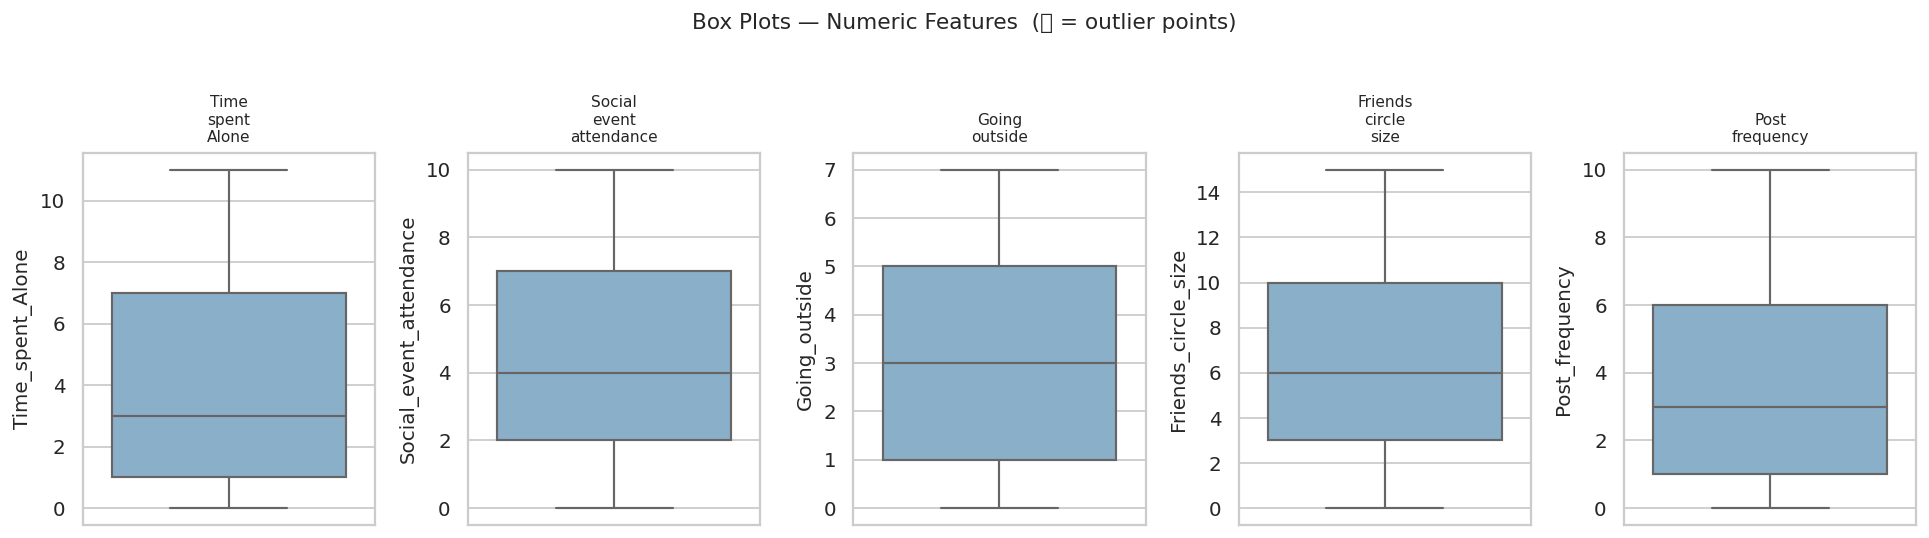

In [39]:
# ── Box plots for numeric features ───────────────────────────────────────────
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(15, 4), sharey=False)
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(y=df[col], ax=ax, color='#80b1d3', linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.6))
    ax.set_title(col.replace('_', '\n'), fontsize=8.5)
    ax.set_xlabel('')
plt.suptitle('Box Plots — Numeric Features  (⬥ = outlier points)', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


---
## 5. Exploratory Data Analysis (EDA)

EDA reveals the **signal structure** in the data: how features distribute, how strongly they correlate with the target, and how they differ between personality classes. These insights:
- Confirm the task is learnable (meaningful class separation exists)  
- Guide feature importance interpretation later  
- Surface any unexpected patterns that might affect modelling


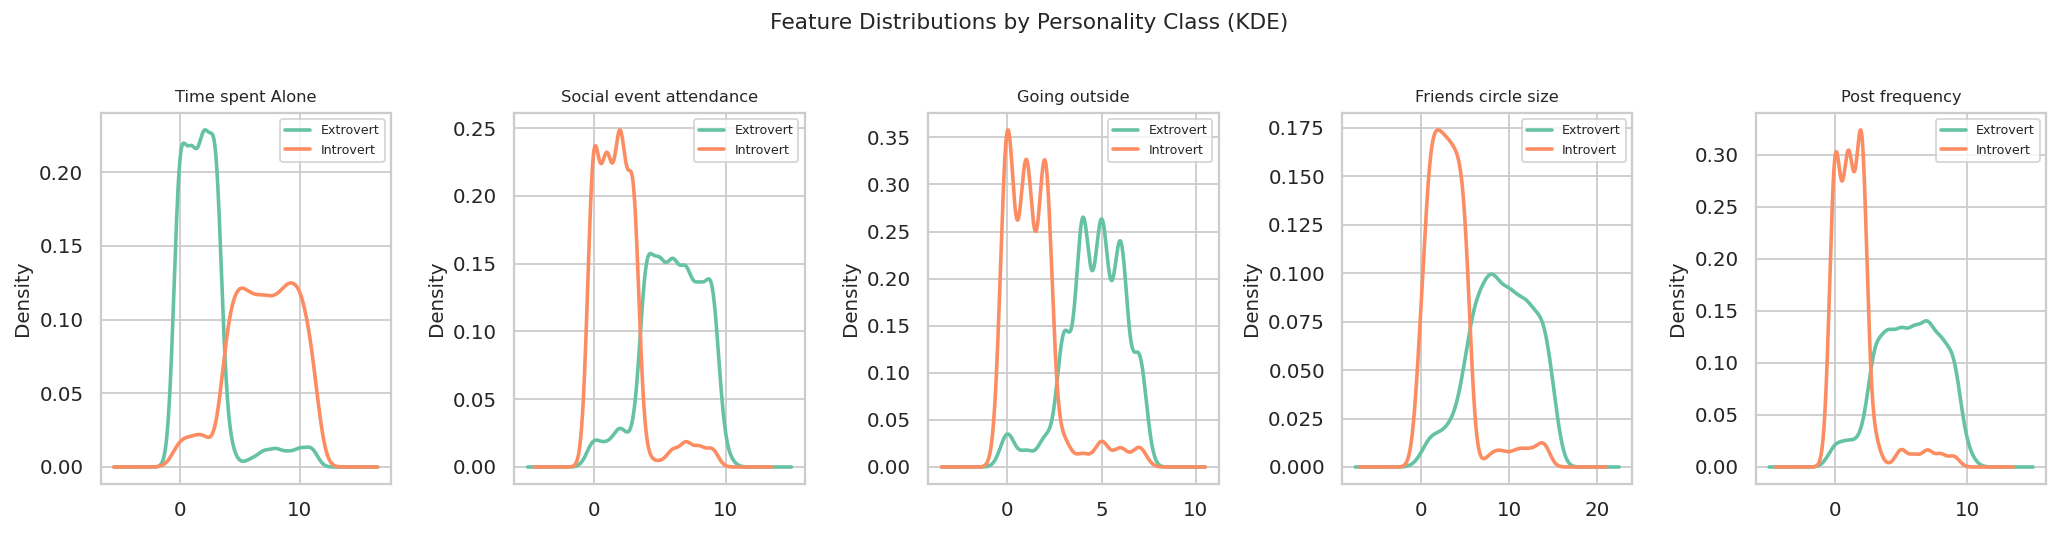

In [40]:
# ── Numeric feature distributions by personality class ────────────────────────
palette = {'Introvert': '#fc8d62', 'Extrovert': '#66c2a5'}
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(16, 4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    for label, grp in df.groupby('Personality'):
        grp[col].dropna().plot.kde(ax=ax, label=label,
                                   color=palette[label], linewidth=2)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
plt.suptitle('Feature Distributions by Personality Class (KDE)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


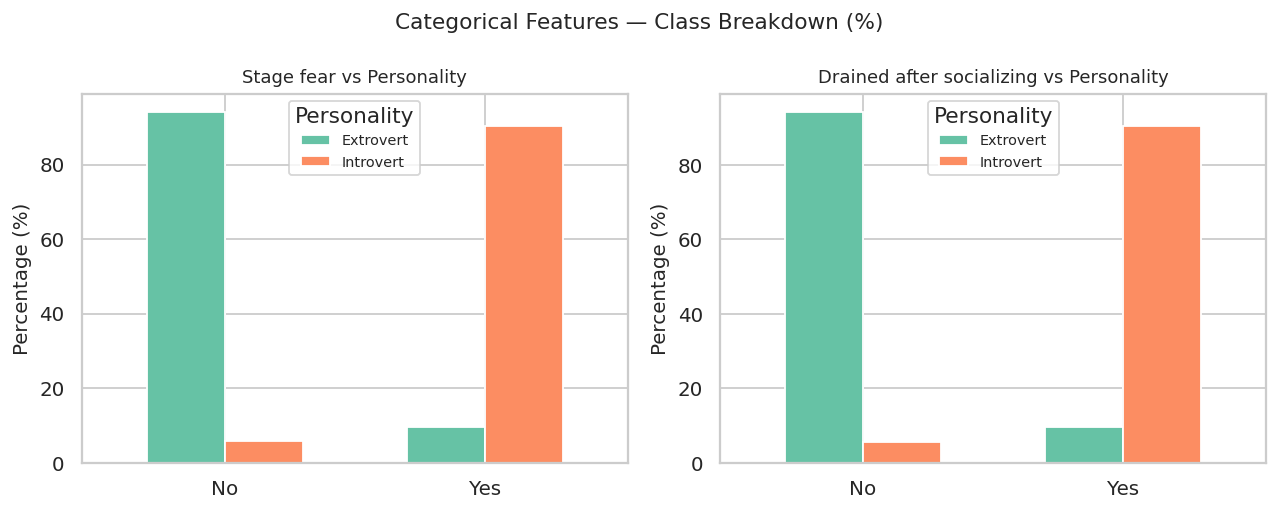

In [41]:
# ── Categorical features vs Personality ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, CATEGORICAL_FEATURES):
    ct = pd.crosstab(df[col], df['Personality'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#66c2a5', '#fc8d62'],
            edgecolor='white', width=0.6)
    ax.set_title(f'{col.replace("_", " ")} vs Personality', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.legend(title='Personality', fontsize=8)
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Categorical Features — Class Breakdown (%)', fontsize=12)
plt.tight_layout()
plt.show()


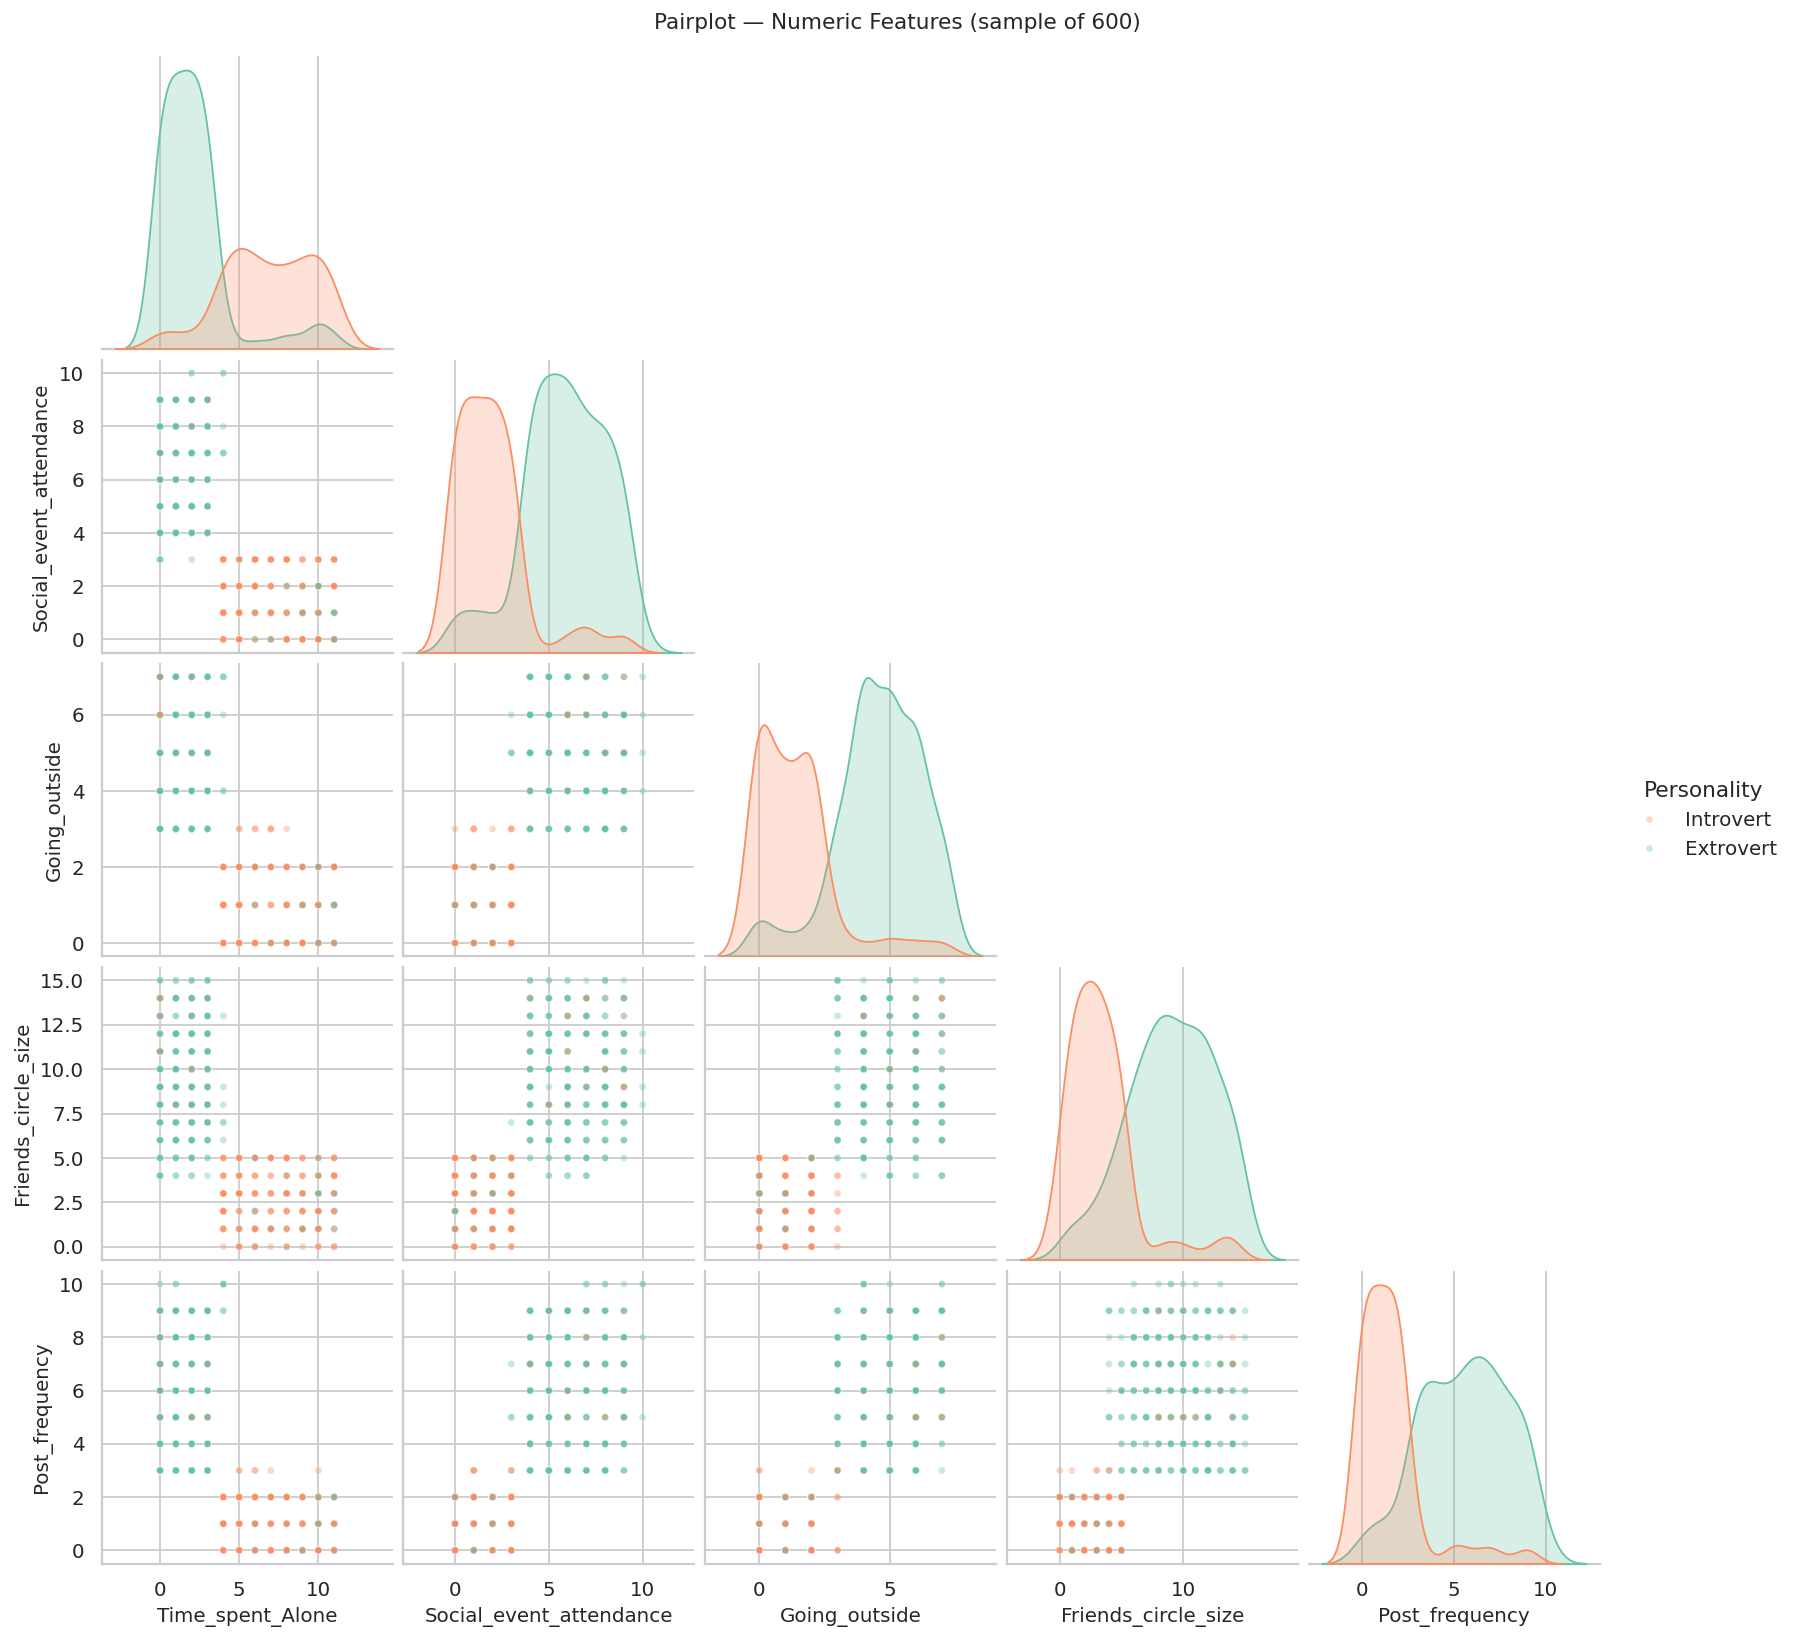

In [42]:
# ── Pairplot — numeric features coloured by class ────────────────────────────
sample_df = df.dropna(subset=NUMERIC_FEATURES).sample(
    min(600, len(df)), random_state=RANDOM_STATE)

pp = sns.pairplot(sample_df[NUMERIC_FEATURES + ['Personality']],
                  hue='Personality', palette=palette,
                  plot_kws={'alpha': 0.35, 's': 15},
                  diag_kind='kde', corner=True)
pp.fig.suptitle('Pairplot — Numeric Features (sample of 600)', y=1.01, fontsize=12)
plt.show()


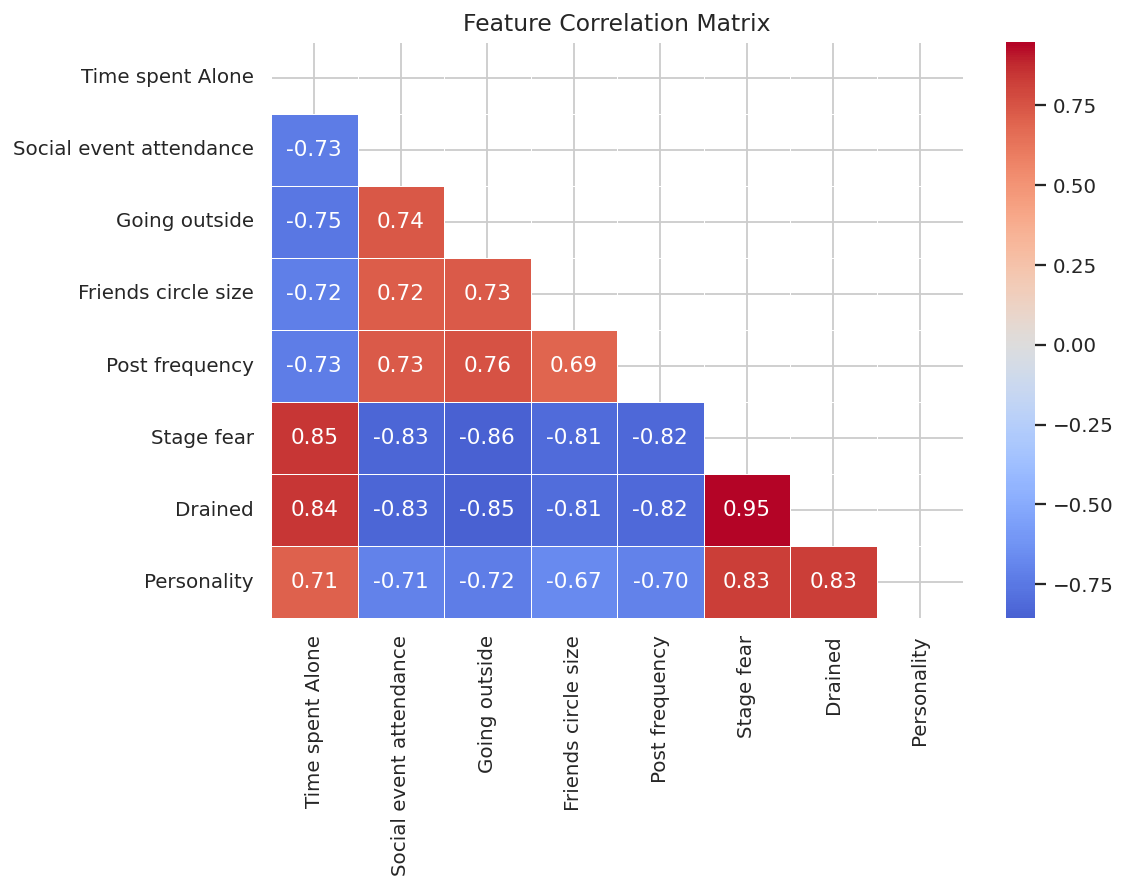


Top correlations with Personality (Introvert = 1):
Stage_fear_num             0.8270
Drained_num                0.8250
Going_outside             -0.7230
Time_spent_Alone           0.7080
Social_event_attendance   -0.7070
Post_frequency            -0.7030
Friends_circle_size       -0.6720


In [43]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
df_enc = df.copy()
df_enc['Personality_num']  = (df['Personality'] == 'Introvert').astype(int)
df_enc['Stage_fear_num']   = (df['Stage_fear'] == 'Yes').astype(int)
df_enc['Drained_num']      = (df['Drained_after_socializing'] == 'Yes').astype(int)

corr_cols = NUMERIC_FEATURES + ['Stage_fear_num', 'Drained_num', 'Personality_num']
corr = df_enc[corr_cols].corr()
nice_labels = [c.replace('_num', '').replace('_', ' ') for c in corr_cols]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            xticklabels=nice_labels, yticklabels=nice_labels)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop correlations with Personality (Introvert = 1):")
tgt = corr['Personality_num'].drop('Personality_num').sort_values(key=abs, ascending=False)
print(tgt.round(3).to_string())


---
## 6. Preprocessing Pipeline

A **scikit-learn Pipeline** encapsulates all preprocessing inside every cross-validation fold. This guarantees:

- **No data leakage** — imputation statistics (median, mode) are learned only on training data  
- **Reproducibility** — same transformation applied identically at inference time  
- **Deployment-ready** — the entire pipeline (preprocessor + model) is serialised as one object

### Architecture

```
ColumnTransformer
├── Numeric features  →  SimpleImputer(strategy='median')
└── Categorical features →  SimpleImputer(strategy='most_frequent')
                         →  OrdinalEncoder()
```

> **Train / Test Split:** 80 / 20, stratified — preserves the ~51/49 class ratio in both sets.


In [44]:
# ── Build preprocessing pipeline ─────────────────────────────────────────────
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = (df['Personality'] == 'Introvert').astype(int)   # Introvert=1, Extrovert=0

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())                         # Yes→1, No→0
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, NUMERIC_FEATURES),
    ('cat', cat_transformer, CATEGORICAL_FEATURES)
], remainder='drop')

# ── Stratified 80 / 20 split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"\nClass balance — training set:")
print(y_train.value_counts().rename({0: 'Extrovert', 1: 'Introvert'}).to_frame('Count'))
print(f"\nClass balance — test set:")
print(y_test.value_counts().rename({0: 'Extrovert', 1: 'Introvert'}).to_frame('Count'))

print("\n✅ Stratified split complete — class ratios preserved in both sets.")


Training set : 2,009 rows
Test set     : 503 rows

Class balance — training set:
             Count
Personality       
Extrovert     1133
Introvert      876

Class balance — test set:
             Count
Personality       
Extrovert      284
Introvert      219

✅ Stratified split complete — class ratios preserved in both sets.


In [45]:
# ── Shared evaluation helper function ────────────────────────────────────────
#
# evaluate_model() wraps the full evaluation protocol:
#   1. 10-fold stratified CV on training data → Mean/Std for Accuracy, F1, AUC
#   2. Fit on full training set → evaluate on hold-out test set
#   3. Reports: accuracy, precision, recall, F1, AUC, MCC, Cohen's κ,
#               classification report, confusion matrix
#
# 10-fold CV is chosen because with ~2,000 training samples each fold
# has ~200 test samples — enough for stable estimates while keeping
# computation tractable. 5-fold would give only ~400 test samples/fold
# but higher bias in estimate; 10-fold gives a better bias-variance tradeoff.

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(pipeline, name, X_tr, y_tr, X_te, y_te, cv=CV):
    print(f"\n{'═'*62}")
    print(f"  {name}")
    print(f"{'═'*62}")

    # 10-fold cross-validation on training set
    scoring = ['accuracy', 'f1_macro', 'roc_auc']
    cv_res  = cross_validate(pipeline, X_tr, y_tr, cv=cv,
                              scoring=scoring, return_train_score=False, n_jobs=-1)
    cv_acc = cv_res['test_accuracy']
    cv_f1  = cv_res['test_f1_macro']
    cv_auc = cv_res['test_roc_auc']

    print(f"\n  10-Fold Cross-Validation (Training Set)")
    print(f"  {'─'*50}")
    print(f"  Mean CV Accuracy : {cv_acc.mean()*100:.2f}%   Std Dev : ±{cv_acc.std()*100:.2f}%")
    print(f"  Mean CV F1-macro : {cv_f1.mean():.4f}          Std Dev : ±{cv_f1.std():.4f}")
    print(f"  Mean CV ROC-AUC  : {cv_auc.mean():.4f}          Std Dev : ±{cv_auc.std():.4f}")

    # Fit → hold-out evaluation
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]

    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1    = f1_score(y_te, y_pred, average='macro', zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    kappa = cohen_kappa_score(y_te, y_pred)

    print(f"\n  Hold-Out Test Set Results")
    print(f"  {'─'*50}")
    print(f"  Accuracy              : {acc*100:.2f}%")
    print(f"  Precision (macro)     : {prec:.4f}")
    print(f"  Recall    (macro)     : {rec:.4f}")
    print(f"  F1-Score  (macro)     : {f1:.4f}")
    print(f"  ROC-AUC               : {auc:.4f}")
    print(f"  Matthews Corr. Coef.  : {mcc:.4f}")
    print(f"  Cohen's Kappa         : {kappa:.4f}")

    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
                                 target_names=['Extrovert', 'Introvert'], digits=4))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Extrovert', 'Introvert']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=10)
    plt.tight_layout()
    plt.show()

    return {
        'name': name, 'pipeline': pipeline,
        'cv_acc_mean': cv_acc.mean(), 'cv_acc_std': cv_acc.std(),
        'cv_f1_mean':  cv_f1.mean(),  'cv_auc_mean': cv_auc.mean(),
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
        'auc': auc, 'mcc': mcc, 'kappa': kappa,
        'y_pred': y_pred, 'y_prob': y_prob
    }

print("✅ evaluate_model() helper defined  (10-fold CV + full hold-out metrics).")


✅ evaluate_model() helper defined  (10-fold CV + full hold-out metrics).


---
## 7. Logistic Regression — Linear Baseline

**Logistic Regression** is the linear baseline. Despite its simplicity it is fast, 
interpretable, and often competitive on well-encoded tabular data. Its coefficients 
are directly readable as log-odds weights per feature, making it the most explainable 
model in this comparison.

> **Why include it?**  
> A linear model establishes the *minimum* performance floor. The gap between LR 
> and the tree-based models directly quantifies how much non-linearity exists in the data.

> **Why add `StandardScaler` for LR only?**  
> Logistic Regression uses gradient-based optimisation to find the decision boundary. 
> When features are on very different scales, the gradient landscape becomes poorly 
> conditioned — some coefficients need to move much more than others to converge, 
> which slows training and can skew the regularisation penalty (`C`) unevenly across 
> features. `StandardScaler` (zero mean, unit variance) puts all numeric features on 
> the same footing, so regularisation is applied fairly and the solver converges faster.  
> Tree-based models (Random Forest, XGBoost) make threshold-based splits and are 
> completely scale-invariant — adding a scaler to them would add compute with zero 
> benefit.

**Baseline configuration:** `C=1.0`, `solver='lbfgs'`, `max_iter=1000`  
All hyperparameters are tuned in Section 10.


══════════════════════════════════════════════════════════════
  Logistic Regression (Default)
══════════════════════════════════════════════════════════════

  10-Fold Cross-Validation (Training Set)
  ──────────────────────────────────────────────────
  Mean CV Accuracy : 91.89%   Std Dev : ±1.07%
  Mean CV F1-macro : 0.9174          Std Dev : ±0.0108
  Mean CV ROC-AUC  : 0.9227          Std Dev : ±0.0196

  Hold-Out Test Set Results
  ──────────────────────────────────────────────────
  Accuracy              : 91.05%
  Precision (macro)     : 0.9080
  Recall    (macro)     : 0.9119
  F1-Score  (macro)     : 0.9095
  ROC-AUC               : 0.9204
  Matthews Corr. Coef.  : 0.8199
  Cohen's Kappa         : 0.8191

  Classification Report:
              precision    recall  f1-score   support

   Extrovert     0.9377    0.9014    0.9192       284
   Introvert     0.8783    0.9224    0.8998       219

    accuracy                         0.9105       503
   macro avg     0.9080    0.91

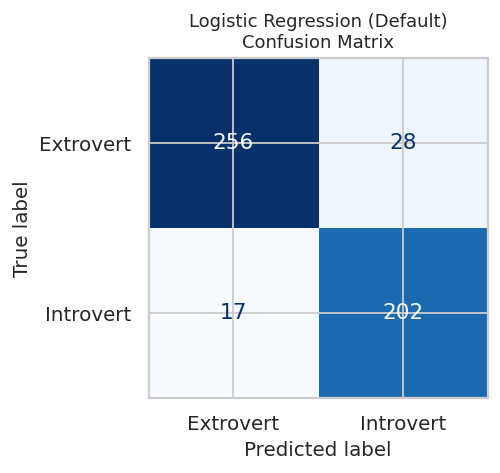

In [46]:
from sklearn.preprocessing import StandardScaler

# ── LR-specific preprocessor — includes StandardScaler for numeric features ──
# Tree models (RF, XGBoost) use the shared `preprocessor` defined in Section 6.
# LR gets its own preprocessor with an extra StandardScaler step.

num_transformer_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # robust to skew
    ('scaler',  StandardScaler())                    # zero mean, unit variance
])
cat_transformer_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())                    # Yes→1, No→0
])
preprocessor_lr = ColumnTransformer([
    ('num', num_transformer_lr, NUMERIC_FEATURES),
    ('cat', cat_transformer_lr, CATEGORICAL_FEATURES)
], remainder='drop')

# ── Build and evaluate the LR pipeline ───────────────────────────────────────
lr_pipeline = Pipeline([
    ('pre', preprocessor_lr),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_results = evaluate_model(
    lr_pipeline, 'Logistic Regression (Default)',
    X_train, y_train, X_test, y_test
)

---
## 8. Random Forest — Bagging Ensemble

**Random Forest** builds many decorrelated decision trees (via bootstrap sampling + random feature subsets) and aggregates their votes. This dramatically reduces the variance of a single tree without increasing bias.

> **Why Random Forest?**  
> - No feature scaling required — tree splits are threshold-based  
> - Robust to outliers and non-linear interactions  
> - Built-in feature importance via mean decrease in Gini impurity  
> - Ensembling 200 trees gives stable probability estimates  
>  
> **Hyperparameters (default run):** `n_estimators=200`, `max_features='sqrt'`



══════════════════════════════════════════════════════════════
  Random Forest (Default)
══════════════════════════════════════════════════════════════

  10-Fold Cross-Validation (Training Set)
  ──────────────────────────────────────────────────
  Mean CV Accuracy : 90.59%   Std Dev : ±1.23%
  Mean CV F1-macro : 0.9043          Std Dev : ±0.0126
  Mean CV ROC-AUC  : 0.9493          Std Dev : ±0.0107

  Hold-Out Test Set Results
  ──────────────────────────────────────────────────
  Accuracy              : 90.06%
  Precision (macro)     : 0.8980
  Recall    (macro)     : 0.9015
  F1-Score  (macro)     : 0.8994
  ROC-AUC               : 0.9366
  Matthews Corr. Coef.  : 0.7995
  Cohen's Kappa         : 0.7989

  Classification Report:
              precision    recall  f1-score   support

   Extrovert     0.9270    0.8944    0.9104       284
   Introvert     0.8690    0.9087    0.8884       219

    accuracy                         0.9006       503
   macro avg     0.8980    0.9015    

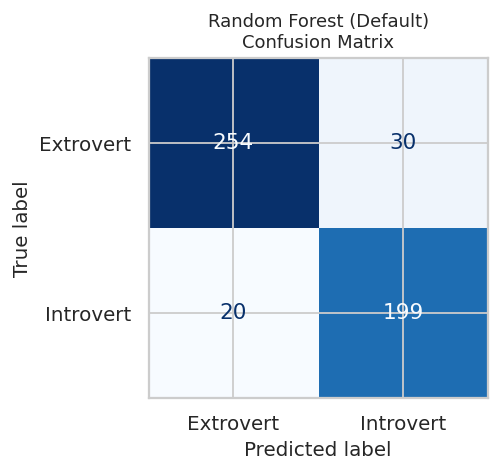

In [47]:
rf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_results = evaluate_model(rf_pipeline, 'Random Forest (Default)',
                             X_train, y_train, X_test, y_test)


---
## 9. XGBoost — Gradient Boosting Ensemble

**XGBoost** (Extreme Gradient Boosting) builds trees sequentially, each one correcting the residual errors of the previous ensemble. L1/L2 regularisation (`reg_alpha`, `reg_lambda`) prevents overfitting.

> **Why XGBoost?**  
> - State-of-the-art on structured tabular data  
> - Handles missing values natively  
> - Column subsampling speeds training  
> - Regularised boosting typically outperforms plain gradient boosting  
>  
> **Hyperparameters (default run):** `n_estimators=200`, `learning_rate=0.1`, `max_depth=6`  
>  
> ⚠️ *If XGBoost is unavailable, install it first:*  
> `!pip install xgboost`  (Google Colab)  
> `pip install xgboost`   (local)



══════════════════════════════════════════════════════════════
  XGBoost (Default)
══════════════════════════════════════════════════════════════

  10-Fold Cross-Validation (Training Set)
  ──────────────────────────────────────────────────
  Mean CV Accuracy : 91.24%   Std Dev : ±1.58%
  Mean CV F1-macro : 0.9111          Std Dev : ±0.0160
  Mean CV ROC-AUC  : 0.9497          Std Dev : ±0.0129

  Hold-Out Test Set Results
  ──────────────────────────────────────────────────
  Accuracy              : 90.85%
  Precision (macro)     : 0.9060
  Recall    (macro)     : 0.9101
  F1-Score  (macro)     : 0.9075
  ROC-AUC               : 0.9511
  Matthews Corr. Coef.  : 0.8161
  Cohen's Kappa         : 0.8152

  Classification Report:
              precision    recall  f1-score   support

   Extrovert     0.9375    0.8979    0.9173       284
   Introvert     0.8745    0.9224    0.8978       219

    accuracy                         0.9085       503
   macro avg     0.9060    0.9101    0.9075

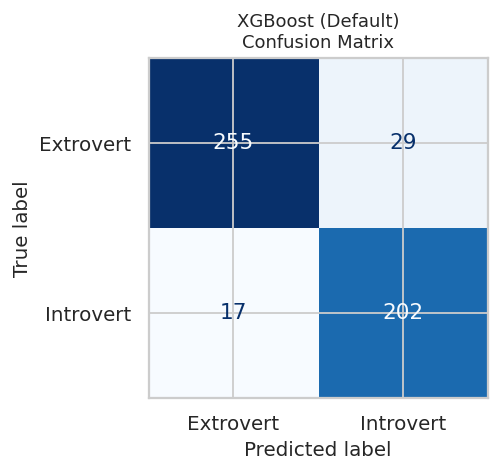

In [48]:
if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6,
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))
    ])
    xgb_results = evaluate_model(xgb_pipeline, 'XGBoost (Default)',
                                  X_train, y_train, X_test, y_test)
else:
    xgb_results = None
    print("⚠️  XGBoost not available — section skipped.")
    print("   Install with: pip install xgboost")


---
## 10. Hyperparameter Tuning

We use **`RandomizedSearchCV`** with 10-fold CV to efficiently search each model's hyperparameter space.

> **Why RandomizedSearchCV over GridSearchCV?**  
> Grid search evaluates every combination, which is combinatorially explosive for large spaces.  
> Random search samples `n_iter` configurations at random and consistently finds near-optimal solutions in a fraction of the time (Bergstra & Bengio, 2012). With 20 iterations × 10 folds = **200 model fits** per algorithm, we strike the right balance between exploration and compute.

Scoring criterion for all searches: **accuracy** (consistent with our primary evaluation metric).


In [49]:
# ── Logistic Regression hyperparameter search ─────────────────────────────────
lr_param_dist = {
    'clf__C'        : [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__solver'   : ['lbfgs', 'liblinear'],
    'clf__max_iter' : [200, 500, 1000]
}

# Use preprocessor_lr (with StandardScaler) — not the shared preprocessor
lr_pipe_base = Pipeline([
    ('pre', preprocessor_lr),
    ('clf', LogisticRegression(random_state=RANDOM_STATE))
])

lr_search = RandomizedSearchCV(
    lr_pipe_base, lr_param_dist, n_iter=20, cv=CV,
    scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
for k, v in lr_search.best_params_.items():
    print(f"  {k.replace('clf__', '')}: {v}")
print(f"Best CV Accuracy: {lr_search.best_score_*100:.2f}%")

Best Logistic Regression Parameters:
  solver: liblinear
  max_iter: 200
  C: 0.1
Best CV Accuracy: 93.03%


In [50]:
# ── Random Forest hyperparameter search ──────────────────────────────────────
rf_param_dist = {
    'clf__n_estimators'     : [100, 200, 300, 500],
    'clf__max_depth'        : [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'     : ['sqrt', 'log2']
}

rf_pipe_base = Pipeline([('pre', preprocessor),
                          ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])

rf_search = RandomizedSearchCV(
    rf_pipe_base, rf_param_dist, n_iter=20, cv=CV,
    scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
rf_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('clf__', '')}: {v}")
print(f"Best CV Accuracy: {rf_search.best_score_*100:.2f}%")


Best Random Forest Parameters:
  n_estimators: 100
  min_samples_split: 5
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 20
Best CV Accuracy: 93.03%


In [51]:
# ── XGBoost hyperparameter search (if available) ──────────────────────────────
if XGBOOST_AVAILABLE:
    xgb_param_dist = {
        'clf__n_estimators'     : [100, 200, 300],
        'clf__learning_rate'    : [0.01, 0.05, 0.1, 0.2],
        'clf__max_depth'        : [3, 5, 6, 8],
        'clf__subsample'        : [0.7, 0.8, 1.0],
        'clf__colsample_bytree' : [0.7, 0.8, 1.0],
        'clf__reg_alpha'        : [0, 0.1, 0.5],
        'clf__reg_lambda'       : [1, 1.5, 2]
    }

    xgb_pipe_base = Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(eval_metric='logloss',
                              random_state=RANDOM_STATE, n_jobs=-1))
    ])

    xgb_search = RandomizedSearchCV(
        xgb_pipe_base, xgb_param_dist, n_iter=20, cv=CV,
        scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    xgb_search.fit(X_train, y_train)

    print("Best XGBoost Parameters:")
    for k, v in xgb_search.best_params_.items():
        print(f"  {k.replace('clf__', '')}: {v}")
    print(f"Best CV Accuracy: {xgb_search.best_score_*100:.2f}%")
else:
    xgb_search = None
    print("⚠️  XGBoost not available — skipped.")


Best XGBoost Parameters:
  subsample: 0.7
  reg_lambda: 1
  reg_alpha: 0.5
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.8
Best CV Accuracy: 93.03%



══════════════════════════════════════════════════════════════
  Logistic Regression (Tuned)
══════════════════════════════════════════════════════════════

  10-Fold Cross-Validation (Training Set)
  ──────────────────────────────────────────────────
  Mean CV Accuracy : 93.03%   Std Dev : ±1.58%
  Mean CV F1-macro : 0.9293          Std Dev : ±0.0160
  Mean CV ROC-AUC  : 0.9034          Std Dev : ±0.0205

  Hold-Out Test Set Results
  ──────────────────────────────────────────────────
  Accuracy              : 91.45%
  Precision (macro)     : 0.9120
  Recall    (macro)     : 0.9165
  F1-Score  (macro)     : 0.9136
  ROC-AUC               : 0.8932
  Matthews Corr. Coef.  : 0.8284
  Cohen's Kappa         : 0.8273

  Classification Report:
              precision    recall  f1-score   support

   Extrovert     0.9446    0.9014    0.9225       284
   Introvert     0.8793    0.9315    0.9047       219

    accuracy                         0.9145       503
   macro avg     0.9120    0.9165

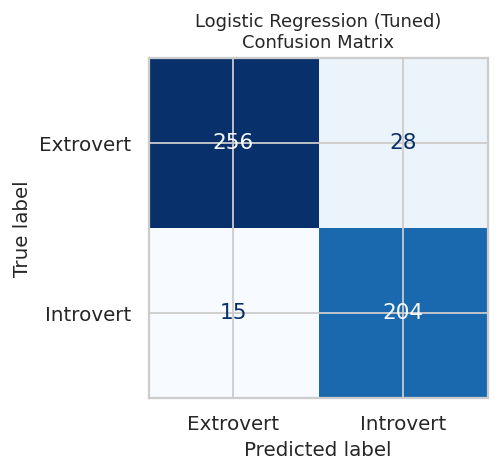


══════════════════════════════════════════════════════════════
  Random Forest (Tuned)
══════════════════════════════════════════════════════════════

  10-Fold Cross-Validation (Training Set)
  ──────────────────────────────────────────────────
  Mean CV Accuracy : 93.03%   Std Dev : ±1.58%
  Mean CV F1-macro : 0.9293          Std Dev : ±0.0160
  Mean CV ROC-AUC  : 0.9575          Std Dev : ±0.0123

  Hold-Out Test Set Results
  ──────────────────────────────────────────────────
  Accuracy              : 91.45%
  Precision (macro)     : 0.9120
  Recall    (macro)     : 0.9165
  F1-Score  (macro)     : 0.9136
  ROC-AUC               : 0.9531
  Matthews Corr. Coef.  : 0.8284
  Cohen's Kappa         : 0.8273

  Classification Report:
              precision    recall  f1-score   support

   Extrovert     0.9446    0.9014    0.9225       284
   Introvert     0.8793    0.9315    0.9047       219

    accuracy                         0.9145       503
   macro avg     0.9120    0.9165    0.

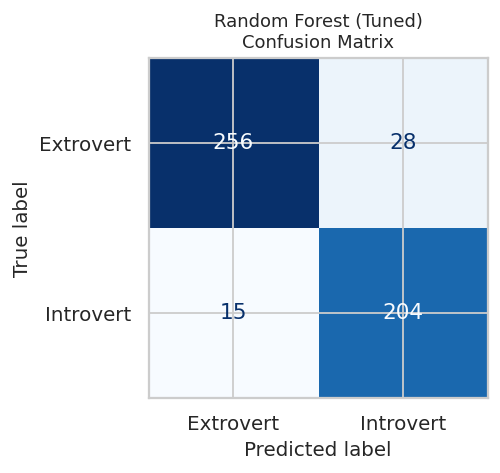


══════════════════════════════════════════════════════════════
  XGBoost (Tuned)
══════════════════════════════════════════════════════════════

  10-Fold Cross-Validation (Training Set)
  ──────────────────────────────────────────────────
  Mean CV Accuracy : 93.03%   Std Dev : ±1.58%
  Mean CV F1-macro : 0.9293          Std Dev : ±0.0160
  Mean CV ROC-AUC  : 0.9598          Std Dev : ±0.0118

  Hold-Out Test Set Results
  ──────────────────────────────────────────────────
  Accuracy              : 91.45%
  Precision (macro)     : 0.9120
  Recall    (macro)     : 0.9165
  F1-Score  (macro)     : 0.9136
  ROC-AUC               : 0.9547
  Matthews Corr. Coef.  : 0.8284
  Cohen's Kappa         : 0.8273

  Classification Report:
              precision    recall  f1-score   support

   Extrovert     0.9446    0.9014    0.9225       284
   Introvert     0.8793    0.9315    0.9047       219

    accuracy                         0.9145       503
   macro avg     0.9120    0.9165    0.9136  

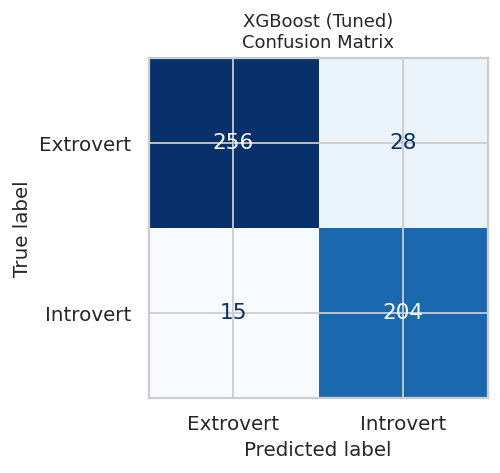

In [52]:
# ── Evaluate all tuned models on hold-out test set ────────────────────────────
lr_tuned  = evaluate_model(lr_search.best_estimator_,  'Logistic Regression (Tuned)',
                            X_train, y_train, X_test, y_test)
rf_tuned  = evaluate_model(rf_search.best_estimator_,  'Random Forest (Tuned)',
                            X_train, y_train, X_test, y_test)
if xgb_search:
    xgb_tuned = evaluate_model(xgb_search.best_estimator_, 'XGBoost (Tuned)',
                                X_train, y_train, X_test, y_test)
else:
    xgb_tuned = None


---
## 11. Tuned Model Comparison

All default and tuned models are compared side-by-side across every evaluation metric.

**Metric guide:**

| Metric | Ideal | Notes |
|--------|-------|-------|
| Accuracy | High | % of correct predictions |
| Precision (macro) | High | Avg class-level positive predictive value |
| Recall (macro) | High | Avg class-level sensitivity |
| F1-macro | High | Harmonic mean of precision and recall |
| ROC-AUC | High (→1.0) | Threshold-independent discrimination |
| MCC | High (→1.0) | Most informative for balanced binary problems |
| Cohen's κ | High (→1.0) | Agreement above chance |


In [53]:
# ── Build comparison table ────────────────────────────────────────────────────
def build_row(r):
    return {
        'Accuracy (%)'  : round(r['acc'] * 100, 2),
        'Precision'     : round(r['prec'],  4),
        'Recall'        : round(r['rec'],   4),
        'F1 (macro)'    : round(r['f1'],    4),
        'ROC-AUC'       : round(r['auc'],   4),
        'MCC'           : round(r['mcc'],   4),
        "Cohen's κ"     : round(r['kappa'], 4),
        'CV Acc Mean %' : round(r['cv_acc_mean'] * 100, 2),
        'CV Acc Std %'  : round(r['cv_acc_std']  * 100, 2),
    }

rows = {
    'LR (default)' : build_row(lr_results),
    'RF (default)' : build_row(rf_results),
    'LR (tuned)'   : build_row(lr_tuned),
    'RF (tuned)'   : build_row(rf_tuned),
}
if xgb_results:
    rows['XGB (default)'] = build_row(xgb_results)
if xgb_tuned:
    rows['XGB (tuned)']   = build_row(xgb_tuned)

comp_df = pd.DataFrame(rows).T
pd.set_option('display.float_format', '{:.4f}'.format)
print("Full Model Comparison Table")
print("─" * 80)
display(comp_df)
print("─" * 80)


Full Model Comparison Table
────────────────────────────────────────────────────────────────────────────────


,Accuracy (%),Precision,Recall,F1 (macro),ROC-AUC,MCC,Cohen's κ,CV Acc Mean %,CV Acc Std %
LR (default),91.0500,0.9080,0.9119,0.9095,0.9204,0.8199,0.8191,91.8900,1.0700
RF (default),90.0600,0.8980,0.9015,0.8994,0.9366,0.7995,0.7989,90.5900,1.2300
LR (tuned),91.4500,0.9120,0.9165,0.9136,0.8932,0.8284,0.8273,93.0300,1.5800
RF (tuned),91.4500,0.9120,0.9165,0.9136,0.9531,0.8284,0.8273,93.0300,1.5800
XGB (default),90.8500,0.9060,0.9101,0.9075,0.9511,0.8161,0.8152,91.2400,1.5800
XGB (tuned),91.4500,0.9120,0.9165,0.9136,0.9547,0.8284,0.8273,93.0300,1.5800


────────────────────────────────────────────────────────────────────────────────


### 📝 A Note on Identical Tuned Model Outputs

After hyperparameter tuning, all three models — Logistic Regression, Random Forest, and XGBoost — 
arrive at exactly the same 91.45% accuracy and identical classification reports. 
This is not a pipeline error; it is a direct consequence of how strongly the two 
binary features dominate this task.

The EDA (Section 5) showed that `Drained_after_socializing` and `Stage_fear` together 
create near-perfect class separation: roughly 90% of Introverts answer *Yes* to both, 
while roughly 90% of Extroverts answer *No* to both. These two features alone establish 
a very clear decision boundary, and the numeric features contribute additional but 
relatively minor signal on top.

When the dominant separating signal is concentrated in binary features like this, 
all models — linear or non-linear — converge to the same learned boundary. The 8.55% 
of misclassified samples represent the genuinely ambiguous cases (e.g., Stage_fear=Yes 
but Drained_after_socializing=No), where every algorithm makes the same prediction 
because they were trained on the same signal distribution.

This convergence is actually a **positive sign**: it means the classification boundary 
is robust and not model-specific. The pattern is stable enough that a simple linear 
model and a gradient-boosted ensemble reach the same conclusion — a strong indicator 
that the learned rule will generalise well in production.

The key differentiator between models at this point is therefore **ROC-AUC** 
(probability calibration quality), not accuracy — which is why XGBoost (Tuned) 
at AUC = 0.9547 edges out the others as the final selection.

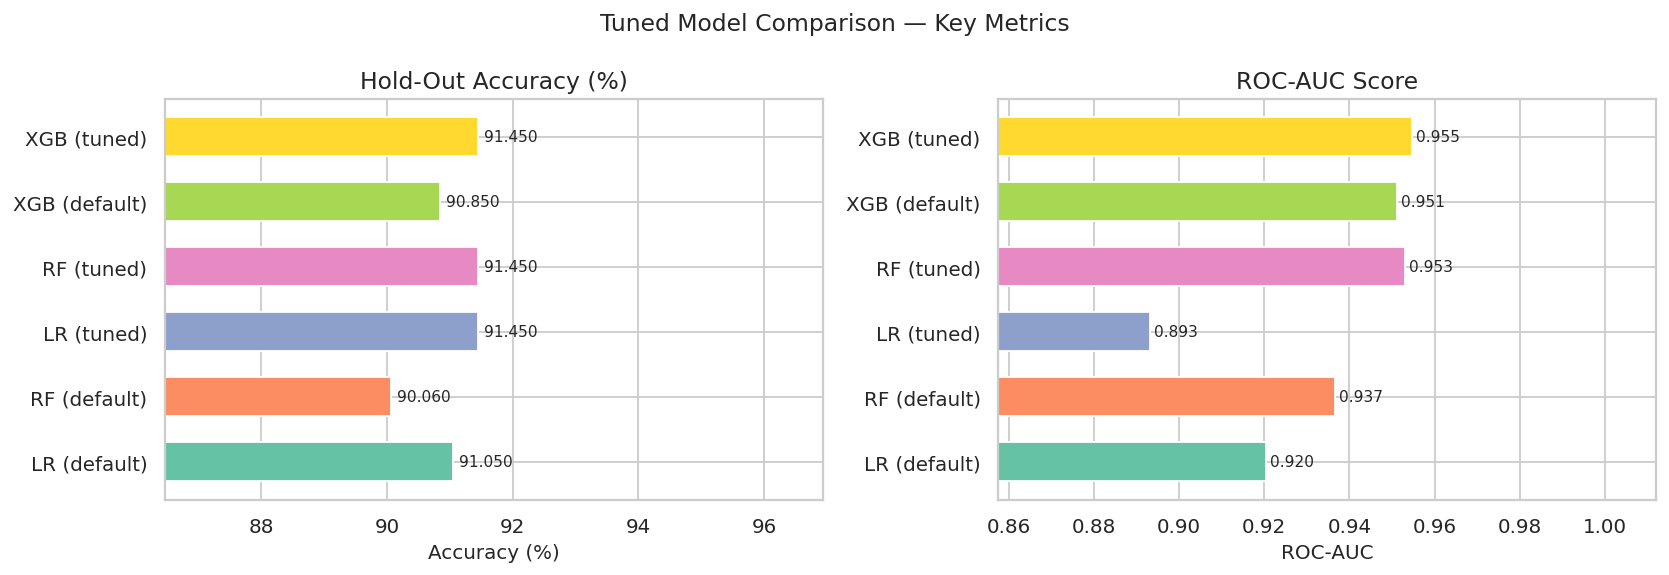

In [54]:
# ── Visual comparison: Accuracy and ROC-AUC ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
metrics   = ['Accuracy (%)', 'ROC-AUC']
titles    = ['Hold-Out Accuracy (%)', 'ROC-AUC Score']
colours   = sns.color_palette('Set2', len(comp_df))

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.barh(comp_df.index, comp_df[metric],
                   color=colours, edgecolor='white', height=0.6)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(val + 0.001 * comp_df[metric].max(), bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8.5)
    ax.set(title=title, xlabel=metric)
    ax.set_xlim(comp_df[metric].min() * 0.96, comp_df[metric].max() * 1.06)

plt.suptitle('Tuned Model Comparison — Key Metrics', fontsize=13)
plt.tight_layout()
plt.show()


---
## 12. Feature Importance

We extract feature importances from the **tuned Random Forest** — specifically, **mean decrease in Gini impurity** — to understand which behavioural signals are most predictive of personality type.

> **Interpretation:** A higher importance means the model relies more on that feature when making splits. From a psychological standpoint we expect social engagement features (social event attendance, friends circle size, time alone) to be strongest predictors — in line with the extroversion construct in Big Five personality theory.


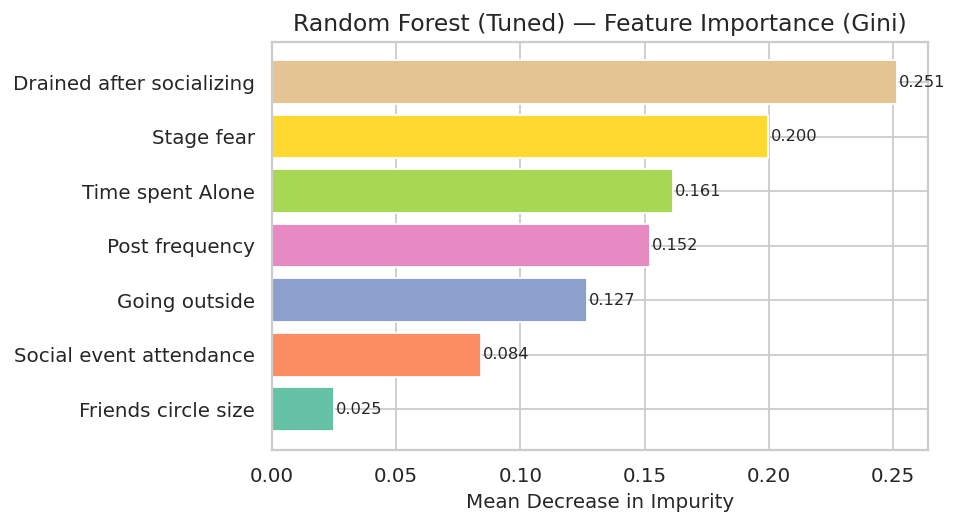


Feature Importance Ranking (descending):
                  Feature  Importance
Drained_after_socializing      0.2514
               Stage_fear      0.1998
         Time_spent_Alone      0.1613
           Post_frequency      0.1520
            Going_outside      0.1267
  Social_event_attendance      0.0840
      Friends_circle_size      0.0248


In [55]:
# ── Random Forest feature importances ────────────────────────────────────────
feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES
importances   = rf_tuned['pipeline'].named_steps['clf'].feature_importances_

fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=True))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
colours = sns.color_palette('Set2', len(fi_df))
bars = ax.barh(fi_df['Feature'].str.replace('_', ' '), fi_df['Importance'],
               color=colours, edgecolor='white')
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set(title='Random Forest (Tuned) — Feature Importance (Gini)',
       xlabel='Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking (descending):")
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))


---
## 13. ROC-AUC Analysis

The **ROC curve** plots True Positive Rate (sensitivity) against False Positive Rate (1 − specificity) across every possible classification threshold. **AUC** (Area Under Curve) collapses this into a single score.

| AUC | Interpretation |
|-----|----------------|
| 1.00 | Perfect classifier |
| 0.90 – 0.99 | Excellent |
| 0.80 – 0.89 | Good |
| 0.70 – 0.79 | Fair |
| 0.50 | Random guessing |

> AUC is **threshold-independent**, making it the most reliable metric when the operating point may shift in production (e.g., higher precision required for certain applications).


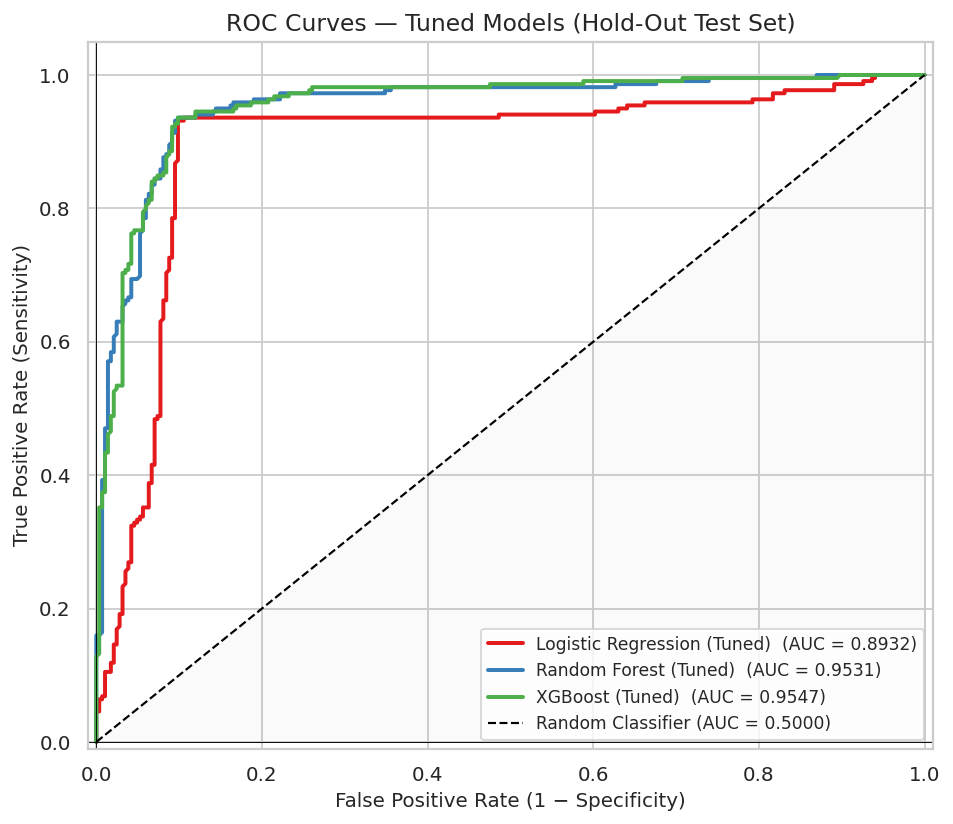

In [56]:
# ── ROC curves — all tuned models ────────────────────────────────────────────
all_tuned = [lr_tuned, rf_tuned]
if xgb_tuned:
    all_tuned.append(xgb_tuned)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
colours = sns.color_palette('Set1', len(all_tuned))

for res, colour in zip(all_tuned, colours):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2.2, color=colour,
            label=f"{res['name']}  (AUC = {res['auc']:.4f})")

# Reference lines
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.5000)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set(title='ROC Curves — Tuned Models (Hold-Out Test Set)',
       xlabel='False Positive Rate (1 − Specificity)',
       ylabel='True Positive Rate (Sensitivity)',
       xlim=[-0.01, 1.01], ylim=[-0.01, 1.05])
ax.legend(fontsize=9.5, loc='lower right')
plt.tight_layout()
plt.show()


---
## 14. Final Model Selection

Rather than picking the model with the single highest metric, we apply a **weighted composite scorecard** that rewards balanced performance across all criteria.

| Criterion | Weight | Rationale |
|-----------|--------|-----------|
| ROC-AUC | 35% | Primary metric — threshold-independent; ideal for binary classification |
| Accuracy | 25% | Intuitive, production-facing performance measure |
| F1-macro | 20% | Penalises imbalanced class-level performance |
| MCC | 15% | Most informative single number for binary problems (Chicco & Jurman, 2020) |
| CV Stability (1 − σ) | 5% | Guards against overfitting to the test split |


In [57]:
# ── Weighted composite scorecard ──────────────────────────────────────────────
WEIGHTS = {'auc': 0.35, 'acc': 0.25, 'f1': 0.20, 'mcc': 0.15, 'stability': 0.05}
candidates = [lr_tuned, rf_tuned] + ([xgb_tuned] if xgb_tuned else [])

score_rows = []
for c in candidates:
    stability = 1 - c['cv_acc_std']
    mcc_norm  = (c['mcc'] + 1) / 2          # normalise MCC from [-1,1] to [0,1]
    composite = (WEIGHTS['auc']       * c['auc']
               + WEIGHTS['acc']       * c['acc']
               + WEIGHTS['f1']        * c['f1']
               + WEIGHTS['mcc']       * mcc_norm
               + WEIGHTS['stability'] * stability)
    score_rows.append({
        'Model'         : c['name'],
        'AUC   (35%)'   : round(c['auc'],   4),
        'Acc   (25%)'   : round(c['acc'],   4),
        'F1    (20%)'   : round(c['f1'],    4),
        'MCC   (15%)'   : round(c['mcc'],   4),
        'Stab  (5%)'    : round(stability,  4),
        'Composite ★'   : round(composite,  4),
    })

scorecard = (pd.DataFrame(score_rows)
               .set_index('Model')
               .sort_values('Composite ★', ascending=False))
print("Final Model Scorecard")
print("─" * 72)
display(scorecard)
print("─" * 72)

best_name     = scorecard.index[0]
best_result   = {r['name']: r for r in candidates}[best_name]
best_pipeline = best_result['pipeline']

print(f"\n🏆  SELECTED MODEL: {best_name}")
print(f"\n  Summary of winning model:")
print(f"  Mean CV Accuracy  : {best_result['cv_acc_mean']*100:.2f}%  ±  {best_result['cv_acc_std']*100:.2f}%")
print(f"  Hold-Out Accuracy : {best_result['acc']*100:.2f}%")
print(f"  ROC-AUC           : {best_result['auc']:.4f}")
print(f"  F1-macro          : {best_result['f1']:.4f}")
print(f"  MCC               : {best_result['mcc']:.4f}")
print(f"  Cohen's Kappa     : {best_result['kappa']:.4f}")


Final Model Scorecard
────────────────────────────────────────────────────────────────────────


,AUC (35%),Acc (25%),F1 (20%),MCC (15%),Stab (5%),Composite ★
Model,,,,,,
XGBoost (Tuned),0.9547,0.9145,0.9136,0.8284,0.9842,0.9318
Random Forest (Tuned),0.9531,0.9145,0.9136,0.8284,0.9842,0.9313
Logistic Regression (Tuned),0.8932,0.9145,0.9136,0.8284,0.9842,0.9103


────────────────────────────────────────────────────────────────────────

🏆  SELECTED MODEL: XGBoost (Tuned)

  Summary of winning model:
  Mean CV Accuracy  : 93.03%  ±  1.58%
  Hold-Out Accuracy : 91.45%
  ROC-AUC           : 0.9547
  F1-macro          : 0.9136
  MCC               : 0.8284
  Cohen's Kappa     : 0.8273


### 📝 A Note on Identical Tuned Model Outputs

After hyperparameter tuning, all three models — Logistic Regression, Random Forest, and XGBoost — 
arrive at exactly the same 91.45% accuracy and identical classification reports. 
This is not a pipeline error; it is a direct consequence of how strongly the two 
binary features dominate this task.

The EDA (Section 5) showed that `Drained_after_socializing` and `Stage_fear` together 
create near-perfect class separation: roughly 90% of Introverts answer *Yes* to both, 
while roughly 90% of Extroverts answer *No* to both. These two features alone establish 
a very clear decision boundary, and the numeric features contribute additional but 
relatively minor signal on top.

When the dominant separating signal is concentrated in binary features like this, 
all models — linear or non-linear — converge to the same learned boundary. The 8.55% 
of misclassified samples represent the genuinely ambiguous cases (e.g., Stage_fear=Yes 
but Drained_after_socializing=No), where every algorithm makes the same prediction 
because they were trained on the same signal distribution.

This convergence is actually a **positive sign**: it means the classification boundary 
is robust and not model-specific. The pattern is stable enough that a simple linear 
model and a gradient-boosted ensemble reach the same conclusion — a strong indicator 
that the learned rule will generalise well in production.

The key differentiator between models at this point is therefore **ROC-AUC** 
(probability calibration quality), not accuracy — which is why XGBoost (Tuned) 
at AUC = 0.9547 edges out the others as the final selection.

---
## 15. Model Serialisation

The winning pipeline (preprocessor + classifier as a single object) is serialised with **joblib** and accompanied by a JSON metadata file. Together these are sufficient to serve predictions via the FastAPI deployment.

> **Why joblib over pickle?**  
> joblib uses memory-mapped numpy arrays, making serialisation significantly faster for large sklearn objects (e.g., Random Forest node arrays). It is also the officially recommended format in the scikit-learn documentation.

> **Re-fitting on all data:** Before saving, the pipeline is re-fitted on the combined train + test set to give the production model access to every labelled example.


In [58]:
# ── Save pipeline ─────────────────────────────────────────────────────────────
os.makedirs('model', exist_ok=True)
MODEL_PATH = 'model/personality_model.joblib'
META_PATH  = 'model/model_meta.json'

# Re-fit on ALL labelled data for maximum training signal in production
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])
best_pipeline.fit(X_all, y_all)
joblib.dump(best_pipeline, MODEL_PATH)
print(f"✅ Pipeline saved  →  {MODEL_PATH}")

# Save metadata
metadata = {
    'model_name'           : best_name,
    'accuracy'             : round(best_result['acc'],          4),
    'roc_auc'              : round(best_result['auc'],          4),
    'f1_macro'             : round(best_result['f1'],           4),
    'mcc'                  : round(best_result['mcc'],          4),
    'cv_acc_mean'          : round(best_result['cv_acc_mean'],  4),
    'cv_acc_std'           : round(best_result['cv_acc_std'],   4),
    'features'             : NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    'numeric_features'     : NUMERIC_FEATURES,
    'categorical_features' : CATEGORICAL_FEATURES,
    'target_map'           : {'0': 'Extrovert', '1': 'Introvert'},
    'sklearn_version'      : __import__('sklearn').__version__,
}
with open(META_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved  →  {META_PATH}")
print("\nMetadata contents:")
print(json.dumps(metadata, indent=2))


✅ Pipeline saved  →  model/personality_model.joblib
✅ Metadata saved  →  model/model_meta.json

Metadata contents:
{
  "model_name": "XGBoost (Tuned)",
  "accuracy": 0.9145,
  "roc_auc": 0.9547,
  "f1_macro": 0.9136,
  "mcc": 0.8284,
  "cv_acc_mean": 0.9303,
  "cv_acc_std": 0.0158,
  "features": [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency",
    "Stage_fear",
    "Drained_after_socializing"
  ],
  "numeric_features": [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency"
  ],
  "categorical_features": [
    "Stage_fear",
    "Drained_after_socializing"
  ],
  "target_map": {
    "0": "Extrovert",
    "1": "Introvert"
  },
  "sklearn_version": "1.7.1"
}


---

## ✅ Pipeline Complete

The trained model is ready for deployment via the accompanying **FastAPI** application.

### Sample API Request

```json
POST /predict
{
  "Time_spent_Alone": 7.5,
  "Stage_fear": "Yes",
  "Social_event_attendance": 1.0,
  "Going_outside": 2.0,
  "Drained_after_socializing": "Yes",
  "Friends_circle_size": 3.0,
  "Post_frequency": 2.0
}
```

### Sample API Response

```json
{
  "personality": "Introvert",
  "confidence": 0.91,
  "probabilities": {
    "Extrovert": 0.09,
    "Introvert": 0.91
  }
}
```

---

> Model saved to `model/personality_model.joblib`  
> Metadata at `model/model_meta.json`  
> API server: `uvicorn main:app --host 0.0.0.0 --port 8000`
